# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [2]:
# TODO 1: choropleth of total_gdp
fig1 = px.choropleth(
    gap_latest, locations="iso_alpha", color="total_gdp",
    hover_name="country", color_continuous_scale="Blues",
    title="COUNT view: Total GDP by country (2007)"
)
fig1.show()

# TODO 2: choropleth of gdpPercap
fig2 = px.choropleth(
    gap_latest, locations="iso_alpha", color="gdpPercap",
    hover_name="country", color_continuous_scale="Greens",
    title="RATE view: GDP per Capita by country (2007)"
)
fig2.show()

# TODO 3: top 5 countries by each -- print both lists
top_total = gap_latest.nlargest(5, "total_gdp")[["country", "total_gdp"]]
top_rate = gap_latest.nlargest(5, "gdpPercap")[["country", "gdpPercap"]]
print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)


Top 5 by total GDP:
            country     total_gdp
134  United States  1.293446e+13
24           China  6.539501e+12
66           Japan  4.035135e+12
58           India  2.722925e+12
47         Germany  2.650871e+12

Top 5 by GDP per capita:
            country    gdpPercap
95          Norway  49357.19017
71          Kuwait  47306.98978
113      Singapore  47143.17964
134  United States  42951.65309
62         Ireland  40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_ The total-GDP list is dominated by large-population, large-economy countries
(e.g. the US, China, Japan), while the GDP-per-capita list surfaces small, wealthy countries
(e.g. Norway, Kuwait, Singapore) that don't appear in the total-GDP list at all. I'd show the
director the GDP-per-capita (rate) map — it answers "how well-off are people in this country,"
which is what the director actually cares about, whereas the total-GDP map mostly just re-draws
a population map and risks the exact "Greenland looks more important than India" trap she warned
about.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

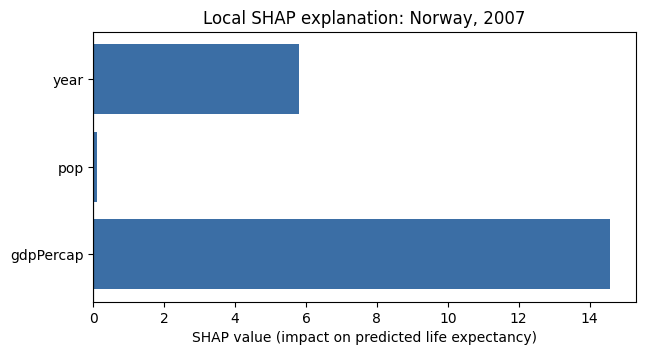

In [3]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model
rf = RandomForestRegressor(n_estimators=200, random_state=0)
rf.fit(X_model, y_model)

# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3: find Norway's row, plot its SHAP contributions
row_idx = gapminder.index[(gapminder.country == "Norway") & (gapminder.year == 2007)][0]
row_pos = gapminder.index.get_loc(row_idx)
vals = shap_values[row_pos]

feature_names = ["gdpPercap", "pop", "year"]
colors = ["#3b6ea5" if v > 0 else "#b5432e" for v in vals]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(feature_names, vals, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("SHAP value (impact on predicted life expectancy)")
ax.set_title("Local SHAP explanation: Norway, 2007")
plt.show()


**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_ `gdpPercap` contributes most positively for Norway, consistent with its very high
income per person, while `year` typically contributes only a small amount and `pop` often
contributes negatively or near zero since Norway's population is small relative to the countries
that drive that feature's global pattern. This is not the same as global feature importance —
globally `gdpPercap` might be the most important feature on average, but the SHAP values here show
the exact signed size of each feature's pull for this one specific country, which a single global
bar chart cannot show.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

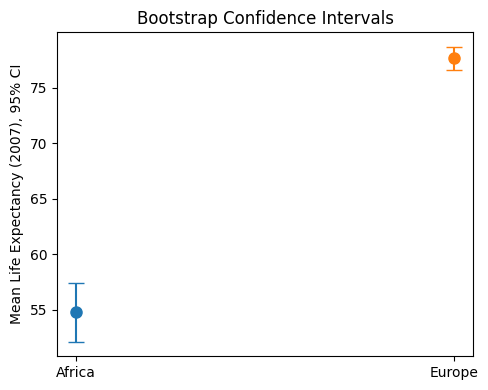

Africa (np.float64(54.80603846153846), np.float64(52.151851442307695), np.float64(57.443240384615386))
Europe (np.float64(77.6486), np.float64(76.5715966666667), np.float64(78.65377833333332))


In [4]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    # TODO 1: resample `values` with replacement n_boot times, take the mean each time,
    # then return (overall mean, 2.5th percentile of boot means, 97.5th percentile)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_boot)
    ])
    return values.mean(), np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5)

# TODO 2: compute CIs for two continents of your choice
continent_a, continent_b = "Africa", "Europe"  # feel free to change these
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

# TODO 3: plot both as error bars (mean +/- CI half-width) on one chart
fig, ax = plt.subplots(figsize=(5, 4))
for i, (name, res) in enumerate([(continent_a, result_a), (continent_b, result_b)]):
    mean, lo, hi = res
    ax.errorbar(i, mean, yerr=[[mean - lo], [hi - mean]], fmt="o", capsize=6, markersize=8)
ax.set_xticks([0, 1]); ax.set_xticklabels([continent_a, continent_b])
ax.set_ylabel("Mean Life Expectancy (2007), 95% CI")
ax.set_title("Bootstrap Confidence Intervals")
plt.tight_layout()
plt.show()
print(continent_a, result_a)
print(continent_b, result_b)


**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_ Africa has the wider confidence interval. This is mainly driven by higher
variation among its countries — life expectancy in Africa ranges much more widely (from
countries hit hard by disease/conflict to relatively higher-income ones) than in Europe, where
countries cluster more tightly around a similar high value. Africa also has more countries in
this dataset, which would normally narrow the interval, so the width here is dominated by the
higher standard deviation rather than a small sample size.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

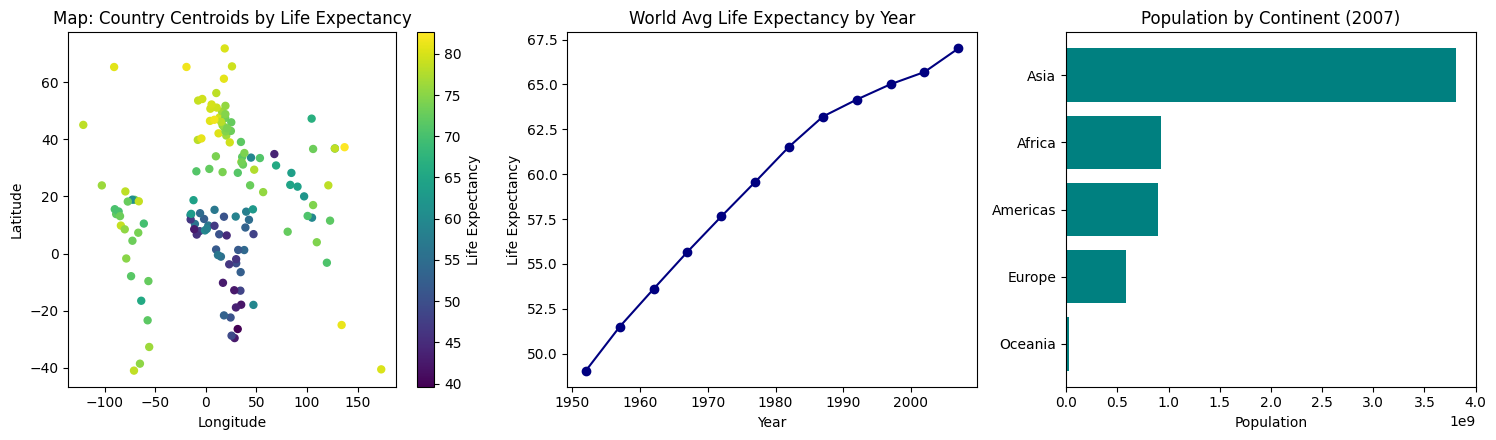

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter (axes[0])
sc = axes[0].scatter(gap_latest.centroid_lon, gap_latest.centroid_lat, c=gap_latest.lifeExp,
                      cmap="viridis", s=25)
fig.colorbar(sc, ax=axes[0], label="Life Expectancy")
axes[0].set_title("Map: Country Centroids by Life Expectancy")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

# TODO 2: world trend line (axes[1])
world_trend = gapminder.groupby("year").lifeExp.mean()
axes[1].plot(world_trend.index, world_trend.values, marker="o", color="navy")
axes[1].set_title("World Avg Life Expectancy by Year")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Life Expectancy")

# TODO 3: population by continent bar chart (axes[2])
pop_by_cont = gap_latest.groupby("continent")["pop"].sum().sort_values()
axes[2].barh(pop_by_cont.index, pop_by_cont.values, color="teal")
axes[2].set_title("Population by Continent (2007)")
axes[2].set_xlabel("Population")

plt.tight_layout()
plt.show()


**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_ I'd keep the world trend line. In a 5-second glance it best answers the
"trends" monitoring question — is global life expectancy rising, flat, or falling — which is
the single most important health-of-the-world signal for a development-focused director,
whereas the map and bar chart are more useful for deeper "which country/region" follow-up
questions rather than an instant morning check.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_ Going forward, I'd standardize on rate-based choropleths
(GDP per capita, not total GDP) for all reports, since count-based maps are dominated by
population size and repeatedly misled us into overweighting large, sparsely-developed regions.
When a journalist asks about a specific country, I would lead with local (SHAP) feature
importance rather than the model's global importance ranking, because the global ranking only
describes average behavior across all countries and cannot answer a question about one country's
individual prediction. Finally, any cross-continent or cross-group comparison of average life
expectancy should never be shown as a bare point estimate — it should always carry a bootstrap
confidence interval, since two continents' point averages can look similar while masking very
different amounts of underlying variation, and reporting them as single numbers would overstate
our certainty.
